In [1]:
print("Test")

Test


In [2]:
# Imports
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

# Configurations
seed = 42

# Paths
DATA_DIR = pathlib.Path("../data/")
ENC2017_ROOT = DATA_DIR / "enc2017"
UD_ET_EDT_ROOT = DATA_DIR / "ud_et_edt"
HOMONYMS_ROOT = DATA_DIR / "homonymous_word_forms"

ENC2017_DIRS = {
    "processed": ENC2017_ROOT / "processed",
    "raw": ENC2017_ROOT / "raw",
}

UD_ET_EDT_DIRS = {
    "processed": UD_ET_EDT_ROOT / "processed",
    "raw": UD_ET_EDT_ROOT / "raw",
}

HOMONYMS_DIRS = {
    "processed": HOMONYMS_ROOT / "processed",
    "annotations": HOMONYMS_ROOT / "annotations",
}

OUTPUT_DIR = pathlib.Path("../outputs/")

MODEL_DIR = pathlib.Path("../models/")

In [3]:
import sys
import os
import pandas as pd
import json
import pathlib
import numpy as np
import torch

from scripts.model.utils import initialize_model
from scripts.model.train import train_token_classification

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
output_dir = "./testing/"
train_path = HOMONYMS_DIRS["processed"] / "homonyms_overall.parquet"
eval_path = UD_ET_EDT_DIRS["processed"] / "UD_dev.csv"
model_dir = "../models/NER_mudel_v2/"
output_dir = "../models/NER_mudel_v2_homonym_full/"
ignore_placeholders = True
dry_run = False
seed = 42
train_batch_size = 8
learning_rate = 5e-5  # 5e-7 for fine-tuning
num_train_epochs = 10
use_cuda = torch.cuda.is_available()

In [12]:
train_df = pd.read_parquet(train_path) if train_path else None
eval_df = pd.read_csv(eval_path) if eval_path else None

# Read labels from the unique labels json
with open("../outputs/unique_labels_old.json", "r") as f:
    unique_labels = json.load(f)

model_bundle = initialize_model(
    str(model_dir),
    unique_labels=unique_labels,
    use_Roberta_tokenizer=False,
    use_fast_tokenizer=False,
    cleanup=True,
)

E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\utils.py:99: UserWarning: Using label mapping from model `id2label` in checkpoint.
  warnings.warn("Using label mapping from model `id2label` in checkpoint.")


In [13]:
print(len(train_df))
display(train_df.head())
# print(len(eval_df))
# display(eval_df.head())

179986


,sentence_id,words,form,pos,labels,infl_type,source
0,0,Edinburghi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
1,0,agulite,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
2,0,mehe,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
3,0,Irvine,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...
4,0,Welshi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-0...


In [14]:
# Replace labels that contain "T" with placeholder dash "-"
eval_df["labels"] = eval_df["labels"].apply(
    lambda label: "-" if ignore_placeholders and "T" in label else label
)

In [15]:
res = train_token_classification(
    model=model_bundle["model"],
    tokenizer=model_bundle["tokenizer"],
    train_df=train_df,
    label_list=unique_labels,
    output_dir=output_dir,
    eval_df=None,
    num_train_epochs=num_train_epochs,
    train_batch_size=train_batch_size,
    learning_rate=learning_rate,
    evaluate_during_training=False if eval_df is None else True,
    use_early_stopping=False,
    patience_n=1,
    early_stopping_method="f1",
    early_stopping_threshold=0.8,
    best_model_dir=os.path.join(output_dir, "best_model"),
    save_model_every_epoch=True,
    device=model_bundle["device"],
    silent=False,
    max_length=128,
    ignore_placeholders=ignore_placeholders,
    dry_run=dry_run,
    seed=seed,
)

print("Training finished.")

Epoch 10/10: 100%|██████████| 986/986 [01:26<00:00, 11.35it/s, train_loss=0.0071]


Training finished.


In [16]:
print("Results:")
print(f"Final training loss: {res['training_stats']['train_loss'][-1]:.4f}")
print(f"Accuracy: {res['training_stats']['train_metrics'][-1]['accuracy']:.2%}")
print(
    f"Precision: {res['training_stats']['train_metrics'][-1]['weighted avg precision']:.2%}"
)
print(
    f"Recall: {res['training_stats']['train_metrics'][-1]['weighted avg recall']:.2%}"
)
print(
    f"F1-score: {res['training_stats']['train_metrics'][-1]['weighted avg f1-score']:.2%}"
)


Results:
Final training loss: 0.0071
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-score: 100.00%


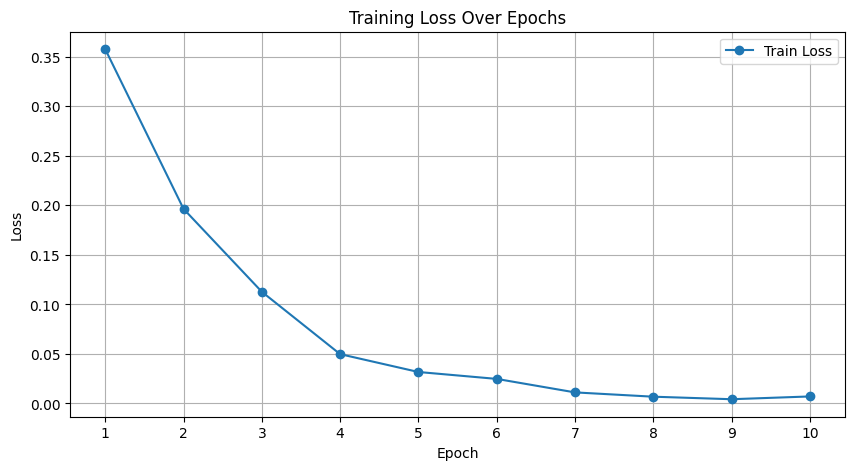

In [17]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.savefig(output_dir + "training_loss.png")
plt.show()